In [1]:
# 03_labeling.ipynb - Створення міток якості сесій
# Мета: визначити якісні сесії на основі rule-based підходу

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.config import DATA_DIR, FIGURES_DIR
from src.data_loader import load_clicks, load_buys

%matplotlib inline

# Налаштування візуалізації
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

# Створюємо папку для збереження графіків
(FIGURES_DIR / 'labeling').mkdir(parents=True, exist_ok=True)

print("Створення міток якості сесій")
print(f"Папка для графіків: {FIGURES_DIR / 'labeling'}")

Створення міток якості сесій
Папка для графіків: d:\University\kursova\kursova\notebooks\..\figures\labeling


In [2]:
print("Завантаження даних")
clicks = load_clicks()
buys = load_buys()

print(f"\n Загальна статистика:")
print(f"   Clicks: {len(clicks):,} записів")
print(f"   Buys:   {len(buys):,} записів")

n_sessions = clicks['Session_ID'].nunique()
print(f"   Унікальних сесій: {n_sessions:,}")

# Сортування даних
print("\n Сортування даних за сесіями та часом")
clicks = clicks.sort_values(['Session_ID', 'Timestamp'])
clicks['event_order'] = clicks.groupby('Session_ID', sort=False).cumcount() + 1

print("Готово")

Завантаження даних

 Загальна статистика:
   Clicks: 33,003,944 записів
   Buys:   1,150,753 записів
   Унікальних сесій: 9,249,729

 Сортування даних за сесіями та часом
Готово


In [4]:
print("Визначення методу якості оцінки")

APPROACH = "rule_based"

print(f"""
Обраний підхід: {APPROACH.upper()}

Rule-based підхід дозволяє:
   • Чітко визначити критерії "якісної" сесії
   • Легко інтерпретувати результати
   • Налаштовувати правила під потреби дослідження

Правила будуть враховувати:
   ✓ Наявність покупки
   ✓ Кількість переглядів
   ✓ Різноманітність категорій
   ✓ Тривалість сесії
""")

Визначення методу якості оцінки

Обраний підхід: RULE_BASED

Rule-based підхід дозволяє:
   • Чітко визначити критерії "якісної" сесії
   • Легко інтерпретувати результати
   • Налаштовувати правила під потреби дослідження

Правила будуть враховувати:
   ✓ Наявність покупки
   ✓ Кількість переглядів
   ✓ Різноманітність категорій
   ✓ Тривалість сесії



In [5]:
print("Підготовка даних")

# Оптимізована агрегація характеристик сесій
print("Обчислення характеристик сесій.")

# Використовуємо agg з ефективними функціями
session_features = clicks.groupby('Session_ID', sort=False).agg(
    total_clicks=('Item_ID', 'count'),
    unique_items=('Item_ID', 'nunique'),
    unique_categories=('Category', 'nunique'),
    session_length_events=('event_order', 'max'),
    duration_minutes=('Timestamp', lambda x: (x.max() - x.min()).total_seconds() / 60)
).reset_index()

print(f" Зібрано {len(session_features):,} сесій")

# Додаємо інформацію про покупки
if len(buys) > 0:
    purchases_per_session = buys.groupby('Session_ID', sort=False).size().reset_index(name='num_purchases')
    session_features = session_features.merge(purchases_per_session, on='Session_ID', how='left')
    session_features['num_purchases'] = session_features['num_purchases'].fillna(0).astype(int)
    session_features['has_purchase'] = (session_features['num_purchases'] > 0).astype(int)
else:
    session_features['num_purchases'] = 0
    session_features['has_purchase'] = 0

# Додаємо часові ознаки
session_times = clicks.groupby('Session_ID', sort=False)['Timestamp'].agg(['min', 'max']).reset_index()
session_times['hour'] = session_times['min'].dt.hour
session_times['day_of_week'] = session_times['min'].dt.dayofweek
session_times['is_weekend'] = (session_times['day_of_week'] >= 5).astype(int)

session_features = session_features.merge(
    session_times[['Session_ID', 'hour', 'day_of_week', 'is_weekend']], 
    on='Session_ID', 
    how='left'
)

print("\nХарактеристики сесій (перші 5):")
display(session_features.head())

Підготовка даних
Обчислення характеристик сесій.
 Зібрано 9,249,729 сесій

Характеристики сесій (перші 5):


,Session_ID,total_clicks,unique_items,unique_categories,session_length_events,duration_minutes,num_purchases,has_purchase,hour,day_of_week,is_weekend
0,1,4,4,1,4,5.850483,0,0,10,0,0
1,2,6,5,1,6,5.987917,0,0,13,0,0
2,3,3,3,1,3,12.422967,0,0,13,2,0
3,4,2,2,1,2,17.241133,0,0,12,0,0
4,6,2,2,1,2,4.102133,0,0,16,6,1


In [6]:
print("RULE-BASED LABELING")

# Налаштування правил 
RULES = {
    'has_purchase_weight': 50,      # покупка дає 50 балів
    'clicks_max_score': 20,         # максимум 20 балів за кліки
    'clicks_divider': 10,           # поділ для нормалізації кліків
    'categories_max_score': 20,     # максимум 20 балів за категорії
    'categories_multiplier': 5,     # множник для категорій
    'duration_max_score': 10,       # максимум 10 балів за тривалість
    'duration_divider': 5,          # поділ для нормалізації тривалості
    'quality_threshold': 50,        # поріг якості (50+ балів)
    'max_clicks_limit': 100         # обмеження для аномалій
}

print(f"\n Правила визначення якісної сесії:")
print(f"   • Покупка: +{RULES['has_purchase_weight']} балів")
print(f"   • Кліки: до {RULES['clicks_max_score']} балів (кожні {RULES['clicks_divider']} кліків = 1 бал)")
print(f"   • Категорії: до {RULES['categories_max_score']} балів (кожна категорія = {RULES['categories_multiplier']} балів)")
print(f"   • Тривалість: до {RULES['duration_max_score']} балів (кожні {RULES['duration_divider']} хв = 1 бал)")
print(f"   • Поріг якості: {RULES['quality_threshold']} балів")
print(f"   • Аномалії: сесії з >{RULES['max_clicks_limit']} кліків штрафуються (×0.5)")

# Розрахунок quality score (векторизовано)
session_features['quality_score'] = 0
session_features['quality_score'] += session_features['has_purchase'] * RULES['has_purchase_weight']
session_features['quality_score'] += np.minimum(session_features['total_clicks'] / RULES['clicks_divider'], RULES['clicks_max_score'])
session_features['quality_score'] += np.minimum(session_features['unique_categories'] * RULES['categories_multiplier'], RULES['categories_max_score'])
session_features['quality_score'] += np.minimum(session_features['duration_minutes'] / RULES['duration_divider'], RULES['duration_max_score'])

# Штрафи за аномалії
session_features.loc[session_features['total_clicks'] > RULES['max_clicks_limit'], 'quality_score'] *= 0.5

# Визначаємо якісні сесії
session_features['is_quality_session'] = (session_features['quality_score'] >= RULES['quality_threshold']).astype(int)

quality_count = session_features['is_quality_session'].sum()
non_quality_count = len(session_features) - quality_count

print(f"\n Результати LABELING:")
print(f"   Якісних сесій:   {quality_count:,} ({quality_count/len(session_features)*100:.2f}%)")
print(f"   Неякісних сесій: {non_quality_count:,} ({non_quality_count/len(session_features)*100:.2f}%)")
print(f"   Співвідношення: 1:{non_quality_count/quality_count:.1f}")

# Приклади якісних та неякісних сесій
print("\n Приклади сесій:")

print("\n Якісні сесії (топ-5):")
quality_examples = session_features[session_features['is_quality_session'] == 1].nlargest(5, 'quality_score')
display(quality_examples[['Session_ID', 'total_clicks', 'unique_categories', 'has_purchase', 
                          'duration_minutes', 'quality_score']])

print("\n Неякісні сесії (топ-5):")
low_quality_examples = session_features[session_features['is_quality_session'] == 0].nsmallest(5, 'quality_score')
display(low_quality_examples[['Session_ID', 'total_clicks', 'unique_categories', 'has_purchase', 
                              'duration_minutes', 'quality_score']])

RULE-BASED LABELING

 Правила визначення якісної сесії:
   • Покупка: +50 балів
   • Кліки: до 20 балів (кожні 10 кліків = 1 бал)
   • Категорії: до 20 балів (кожна категорія = 5 балів)
   • Тривалість: до 10 балів (кожні 5 хв = 1 бал)
   • Поріг якості: 50 балів
   • Аномалії: сесії з >100 кліків штрафуються (×0.5)

 Результати LABELING:
   Якісних сесій:   509,608 (5.51%)
   Неякісних сесій: 8,740,121 (94.49%)
   Співвідношення: 1:17.2

 Приклади сесій:

 Якісні сесії (топ-5):


,Session_ID,total_clicks,unique_categories,has_purchase,duration_minutes,quality_score
6862590,8578238,98,5,1,146.456567,89.8
5327944,6659931,97,5,1,79.998700,89.7
6892576,8615721,95,7,1,213.189567,89.5
7924392,9905491,95,7,1,249.748183,89.5
5164296,6455371,94,5,1,66.560467,89.4



 Неякісні сесії (топ-5):


,Session_ID,total_clicks,unique_categories,has_purchase,duration_minutes,quality_score
66,83,1,1,0,0.0,5.1
67,84,1,1,0,0.0,5.1
120,151,1,1,0,0.0,5.1
121,152,1,1,0,0.0,5.1
170,213,1,1,0,0.0,5.1


АНАЛІЗ БАЛАНСУ КЛАСІВ

 Розподіл класів:
   Якісні (1):         509,608 ( 5.51%)
   Неякісні (0):     8,740,121 (94.49%)
   Співвідношення: 1:17.15


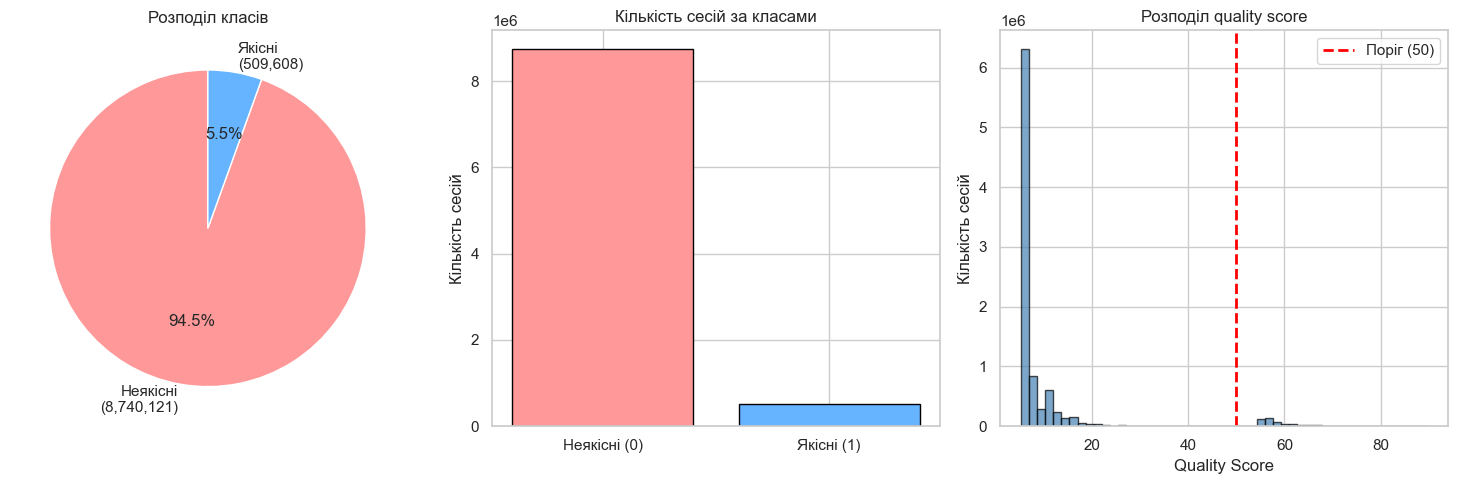


 Сильний дисбаланс класів!

 Рекомендації для моделі
   1. Використовувати 'class_weight' при тренуванні
   2. Застосувати oversampling/undersampling
   3. Використовувати метрики: F1-score, ROC-AUC (не accuracy)


In [7]:
print("АНАЛІЗ БАЛАНСУ КЛАСІВ")

quality_count = session_features['is_quality_session'].sum()
non_quality_count = len(session_features) - quality_count
quality_ratio = quality_count / len(session_features)

print(f"\n Розподіл класів:")
print(f"   Якісні (1):    {quality_count:>12,} ({quality_ratio*100:>5.2f}%)")
print(f"   Неякісні (0):  {non_quality_count:>12,} ({(1-quality_ratio)*100:>5.2f}%)")
print(f"   Співвідношення: 1:{non_quality_count/quality_count:.2f}")

# Візуалізація
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
colors = ['#ff9999', '#66b3ff']
labels = [f'Неякісні\n({non_quality_count:,})', f'Якісні\n({quality_count:,})']
axes[0].pie([non_quality_count, quality_count], labels=labels, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Розподіл класів')

# Bar chart
axes[1].bar(['Неякісні (0)', 'Якісні (1)'], [non_quality_count, quality_count], 
            color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[1].set_title('Кількість сесій за класами')
axes[1].set_ylabel('Кількість сесій')

# Розподіл quality score
session_features['quality_score'].hist(bins=50, ax=axes[2], edgecolor='black', alpha=0.7, color='steelblue')
axes[2].axvline(RULES['quality_threshold'], color='red', linestyle='--', linewidth=2, 
                label=f'Поріг ({RULES["quality_threshold"]})')
axes[2].set_title('Розподіл quality score')
axes[2].set_xlabel('Quality Score')
axes[2].set_ylabel('Кількість сесій')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'labeling/class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

# Рекомендації щодо дисбалансу
if quality_ratio < 0.2 or quality_ratio > 0.8:
    print("\n Сильний дисбаланс класів!")
    print("\n Рекомендації для моделі")
    print("   1. Використовувати 'class_weight' при тренуванні")
    print("   2. Застосувати oversampling/undersampling")
    print("   3. Використовувати метрики: F1-score, ROC-AUC (не accuracy)")
else:
    print("\n Баланс класів прийнятний для моделювання")

In [9]:
print("Збереження результатів")

# Зберігаємо мітки
labels_df = session_features[['Session_ID', 'is_quality_session', 'quality_score']].copy()
labels_df.to_csv(DATA_DIR / 'session_labels.csv', index=False)
print(f" Мітки збережено: {DATA_DIR / 'session_labels.csv'}")

# Зберігаємо характеристики сесій
session_features.to_csv(DATA_DIR / 'session_features.csv', index=False)
print(f" Характеристики сесій: {DATA_DIR / 'session_features.csv'}")

# Зберігаємо метадані labeling
labeling_info = {
    'approach': APPROACH,
    'rules': RULES,
    'total_sessions': int(len(session_features)),
    'quality_sessions': int(quality_count),
    'non_quality_sessions': int(non_quality_count),
    'quality_ratio': float(quality_ratio),
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

import json
with open(DATA_DIR / 'labeling_info.json', 'w', encoding='utf-8') as f:
    json.dump(labeling_info, f, indent=4, ensure_ascii=False)

print(f"Метадані збережено: {DATA_DIR / 'labeling_info.json'}")

print("Підсумки LABELING")
print(f"""
Обраний підхід:     {APPROACH}
Всього сесій:       {len(session_features):,}
Якісних сесій:      {quality_count:,} ({quality_ratio*100:.1f}%)
Неякісних сесій:    {non_quality_count:,} ({(1-quality_ratio)*100:.1f}%)
""")

Збереження результатів
 Мітки збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\session_labels.csv
 Характеристики сесій: d:\University\kursova\kursova\notebooks\..\data\yoochoose\session_features.csv
Метадані збережено: d:\University\kursova\kursova\notebooks\..\data\yoochoose\labeling_info.json
Підсумки LABELING

Обраний підхід:     rule_based
Всього сесій:       9,249,729
Якісних сесій:      509,608 (5.5%)
Неякісних сесій:    8,740,121 (94.5%)

